In [26]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Arxiv

In [27]:
df = pd.read_json("./../data/analyzed/arxiv.jsonl", lines=True)

print(df.columns.tolist())

dep_df = df["dependency_distribution"].apply(pd.Series).fillna(0)
dep_df["year"] = df["year"]

['paperId', 'title', 'abstract', 'year', 'authors', 'venue', 'publicationDate', 'citationCount', 'influentialCitationCount', 'fieldsOfStudy', 'publicationTypes', 'journal', 'isOpenAccess', 'externalIds', 'url', 'tldr', 'source', 'text_raw', 'text_clean', 'text_lemma', 'word_count', 'sentence_count', 'month', 'em_dash_count', 'em_dash_per_1k_words', 'semicolon_count', 'semicolon_per_1k_words', 'colon_count', 'colon_per_1k_words', 'clause_depth', 'dependency_entropy', 'dependency_length', 'dependency_length_norm', 'dependency_distribution', 'coordination_count', 'coordination_density', 'sentence_depth_std', 'list_of_three', 'clause_depth_per_sentence', 'dependency_entropy_normalized', 'coordination_count_per_1k_words', 'sentence_depth_cv', 'list_of_three_per_1k_words', 'word_finding', 'word_interplay', 'word_realm', 'word_insight', 'word_notably', 'word_particularly', 'word_meticulously', 'word_while', 'word_within', 'word_across', 'word_additionally', 'marker_words_total', 'marker_words

In [28]:
top_entropy = df.sort_values("dependency_entropy", ascending=False).head(5)
print(top_entropy[["text_raw", "dependency_entropy"]])

                                               text_raw  dependency_entropy
249   Measuring Machine Intelligence Through Visual ...            3.101094
1583  BadLlama: cheaply removing safety fine-tuning ...            3.080633
1930  SafePassage: High-Fidelity Information Extract...            3.079941
1646  PROC2PDDL: Open-Domain Planning Representation...            3.063901
1478  "Genlangs" and Zipf's Law: Do languages genera...            3.050495


In [29]:
bottom_entropy = df.sort_values("dependency_entropy", ascending=True).head(5)
print(bottom_entropy[["text_raw", "dependency_entropy"]])

                                              text_raw  dependency_entropy
5    A Notation for Markov Decision Processes This ...            1.841390
852  The Book of Why: Review This is a review of "T...            1.905420
528  'Viral' Turing Machines, Computation from Nois...            2.218697
233  Semantic Parsing with Semi-Supervised Sequenti...            2.245989
166  The Search for Computational Intelligence We d...            2.315933


<Axes: >

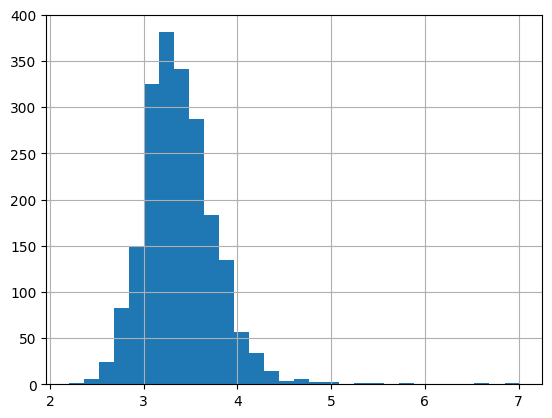

In [30]:
df["dependency_length"].hist(bins=30)

<Axes: >

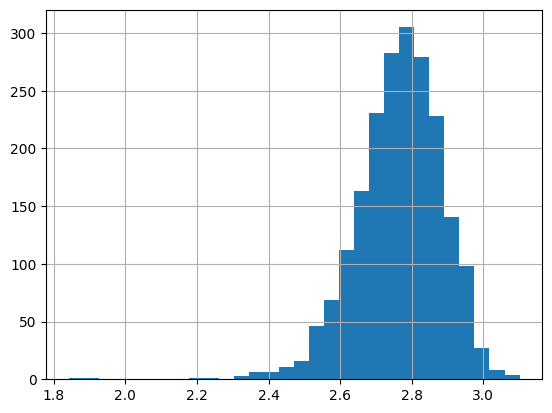

In [31]:
df["dependency_entropy"].hist(bins=30)

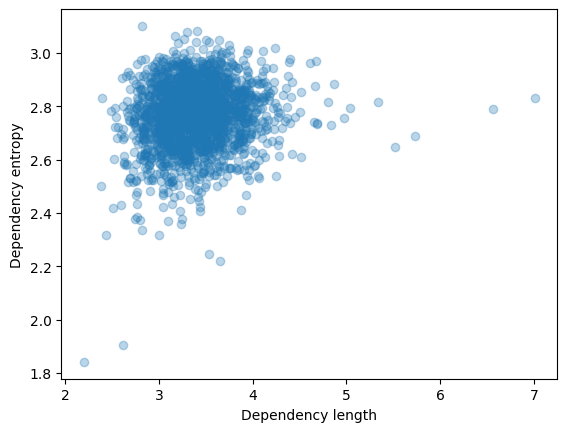

In [32]:
plt.scatter(
    df["dependency_length"],
    df["dependency_entropy"],
    alpha=0.3
)
plt.xlabel("Dependency length")
plt.ylabel("Dependency entropy")
plt.show()

In [33]:
dep_yearly = dep_df.groupby("year").mean()

In [34]:
dep_norm = dep_df.drop(columns="year").div(
    dep_df.drop(columns="year").sum(axis=1),
    axis=0
)

dep_norm["year"] = dep_df["year"]

In [35]:
dep_yearly = dep_norm.groupby("year").mean()

In [36]:
dep_yearly.tail()

,amod,nsubj,appos,cc,conj,prep,compound,pobj,det,aux,...,meta,neg,quantmod,oprd,parataxis,prt,preconj,csubjpass,expl,intj
year,,,,,,,,,,,,,,,,,,,,,
2022,0.132479,0.054376,0.013046,0.033838,0.038663,0.117442,0.088814,0.111419,0.085038,0.027782,...,0.000730,0.001779,0.001200,0.000828,0.000218,0.000546,0.000725,0.000059,0.000450,0.000269
2023,0.131968,0.054735,0.011341,0.034243,0.040601,0.121186,0.081575,0.113701,0.080697,0.027771,...,0.000612,0.001541,0.000765,0.000479,0.000137,0.000720,0.001174,0.000055,0.000630,0.000172
2024,0.135920,0.054976,0.013163,0.033111,0.039740,0.121613,0.086575,0.111556,0.075247,0.022685,...,0.000559,0.001727,0.001264,0.000932,0.000249,0.000642,0.001195,0.000303,0.000410,0.000223
2025,0.149153,0.056440,0.016702,0.035172,0.042916,0.111906,0.085376,0.104516,0.068225,0.019832,...,0.000677,0.001079,0.001386,0.000837,0.000240,0.000456,0.001090,0.000096,0.000364,0.000195
2026,0.163922,0.061159,0.018613,0.039412,0.049273,0.100224,0.088870,0.095490,0.057041,0.017299,...,0.000680,0.001857,0.001677,0.000292,0.000236,0.000523,0.001292,0.000160,0.000221,0.000214


In [37]:
change = dep_yearly.loc[2024] - dep_yearly.loc[2016]
change.sort_values(ascending=False).head(10)

dobj        0.010171
compound    0.007680
nummod      0.004986
advcl       0.004799
npadvmod    0.004192
conj        0.003961
nsubj       0.003847
appos       0.003681
pcomp       0.003593
poss        0.003211
dtype: float64

In [38]:
change.sort_values().head(10)

det         -0.022456
auxpass     -0.007215
nsubjpass   -0.007093
pobj        -0.005614
relcl       -0.002511
aux         -0.002199
attr        -0.001997
xcomp       -0.001824
acl         -0.001760
prep        -0.001605
dtype: float64

<Axes: xlabel='year'>

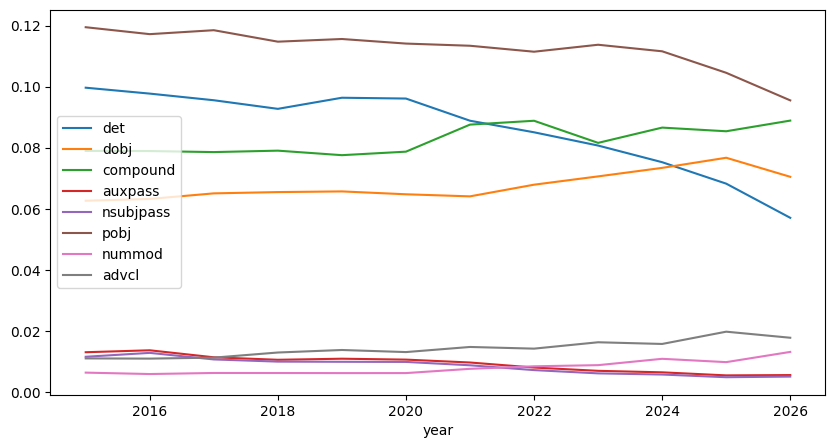

In [39]:
top = change.abs().sort_values(ascending=False).head(8).index

dep_yearly[top].plot(figsize=(10,5))

In [40]:
high = df.nlargest(200, "dependency_entropy")
low = df.nsmallest(200, "dependency_entropy")

high_dep = high["dependency_distribution"].apply(pd.Series).fillna(0).mean()
low_dep = low["dependency_distribution"].apply(pd.Series).fillna(0).mean()

(high_dep - low_dep).sort_values(ascending=False).head(10)

advmod      6.335
dobj        5.890
nsubj       5.665
aux         4.980
conj        3.110
cc          2.885
ROOT        2.735
compound    2.580
det         2.515
ccomp       2.365
dtype: float64

In [41]:
pre = dep_norm[dep_norm["year"] < 2022].drop(columns="year")
post = dep_norm[dep_norm["year"] >= 2022].drop(columns="year")

(post.mean() - pre.mean()).sort_values(ascending=False).head(10)

amod        0.008074
dobj        0.007607
compound    0.005947
conj        0.004757
appos       0.004237
advcl       0.004062
nummod      0.003368
cc          0.002985
npadvmod    0.002788
nmod        0.002220
dtype: float64

       adverbial_lead_count  sentence_count  sentence_count  \
count           2040.000000     2040.000000     2040.000000   
mean               0.828922        7.090686        7.248529   
std                1.041864        2.313597        2.337929   
min                0.000000        1.000000        1.000000   
25%                0.000000        5.000000        6.000000   
50%                1.000000        7.000000        7.000000   
75%                1.000000        9.000000        9.000000   
max                6.000000       16.000000       16.000000   

       adverbial_lead_rate  
count          2040.000000  
mean              0.106258  
std               0.127804  
min               0.000000  
25%               0.000000  
50%               0.090909  
75%               0.166667  
max               0.714286  
                                               text_raw  \
1605  A Survey of Personality, Persona, and Profile ...   
1653  Fairness in Large Language Models: A Taxonomic.

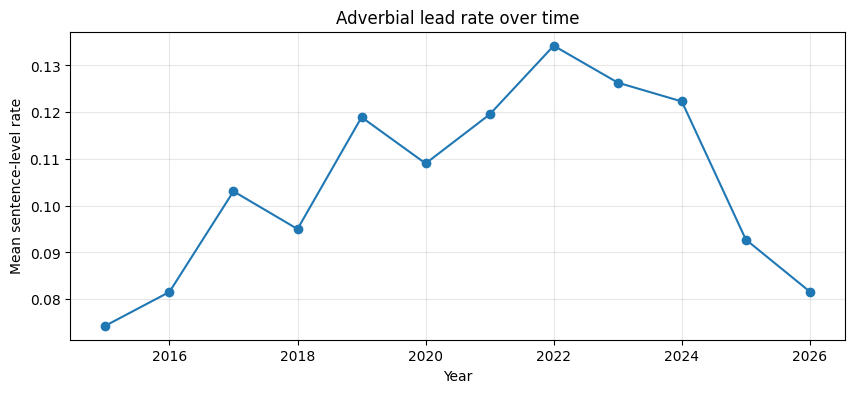

In [42]:
import spacy
import matplotlib.pyplot as plt

nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])


def adverbial_lead_summary(text):
    doc = nlp(str(text))
    sentence_total = 0
    lead_total = 0
    lead_examples = []

    for sent in doc.sents:
        tokens = [token for token in sent if not token.is_space]
        if not tokens:
            continue

        sentence_total += 1
        lead = tokens[0]
        lead_is_adverbial = (
            lead.dep_ in {"advmod", "discourse"}
            and lead.head == sent.root
            and lead.i == sent.start
        )

        if lead_is_adverbial:
            lead_total += 1
            if len(lead_examples) < 3:
                lead_examples.append(sent.text)

    return pd.Series(
        {
            "adverbial_lead_count": lead_total,
            "sentence_count": sentence_total,
            "adverbial_lead_rate": lead_total / sentence_total if sentence_total else 0.0,
            "lead_examples": lead_examples,
        }
    )


lead_features = df["text_raw"].fillna("").astype(str).apply(adverbial_lead_summary)
df = pd.concat([df, lead_features], axis=1)

print(df[["adverbial_lead_count", "sentence_count", "adverbial_lead_rate"]].describe())
print(
    df.loc[
        df["adverbial_lead_rate"].nlargest(5).index,
        ["text_raw", "lead_examples", "adverbial_lead_rate"],
    ]
)

lead_by_year = (
    df.groupby("year", as_index=False)["adverbial_lead_rate"]
    .mean()
    .sort_values("year")
)

plt.figure(figsize=(10, 4))
plt.plot(lead_by_year["year"], lead_by_year["adverbial_lead_rate"], marker="o")
plt.title("Adverbial lead rate over time")
plt.ylabel("Mean sentence-level rate")
plt.xlabel("Year")
plt.grid(alpha=0.3)
plt.show()
